<a href="https://colab.research.google.com/github/jwsn8667/GEOG5003M/blob/main/GEOG5003_A2_201913950.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5003M Final Assignment

Student ID number:

GitHub repo link:

Declared word count: X out of 1,500 words (markdown cells only, excluding readme)

# Introduction


*   Local authorities' distinct characters are recognised in official statistics *e.g.*, in the English Indices of Deprivation shrinkage is applied so that deprivation scores for smaller areas are constrained by observations at the local authority level.
*   Local and place-based policy
*   Social research aimed at understanding variation at the local level
*   Local authorities have climate policies, responsibility as social landlords *etc*.


#Analysis

###Processing Environment

In [1]:
# @title
## Importing standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# @title
## Additional packages for processing and visualising spatial data
!pip install contextily
!pip install matplotlib-map-utils

import geopandas as gpd
import contextily as ctx
import requests
import json
import warnings

from pyproj import CRS
from shapely.geometry import shape
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 98.1 MB/s eta 0:00:00


In [3]:
import scipy

In [4]:
import sklearn

###Data Pre-Processing

####**Area of Interest**

A single UK local authority district is taken as the study area, the City of Sheffield.  Variations within Sheffield are studied at the middle-layer super output area or 'MSOA' -level, comprising between 2,000 and 6,000 households or a population of 5,000 - 15,000 usual residents [**X**].  MSOAs are a standard statistical geography first defined for the 2001 Census of England and Wales, defined to have broadly similar population characteristics within their boundaries and to be stable over time, with some minor boundary changes between Censuses to account for population change [**Y**]. Studying energy use at the MSOA-level provides sufficient resolution to map spatial patterns, while facilitating comparison with other official datasets.

In [5]:
# @title
## Load Sheffield MSOA boundaires from Open Geography Portal API
url = 'https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Middle_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFC_V7/FeatureServer/0/query?outFields=*&where=MSOA21NM%20like%20%27Sheffield%25%27&outFields=MSOA21CD,MSOA21NM&outSR=4326&f=geojson'
msoa = pd.DataFrame(requests.get(url).json()['features'])


## Parse geometry attributes as geojson, flatten 'properties' as two columns, opposed to a nested table and drop redundant columns.
msoa['shapely_geometry'] = msoa['geometry'].apply(shape)
msoa = msoa.drop('geometry', axis=1)
msoa = pd.json_normalize(msoa['properties']).join(msoa)
msoa = msoa.drop(['properties', 'type'], axis=1)


## Read dataframe to a geopandas GeoDataFrame to visualise spatial data.
geo_msoa = gpd.GeoDataFrame(msoa, geometry='shapely_geometry', crs='EPSG:4326')

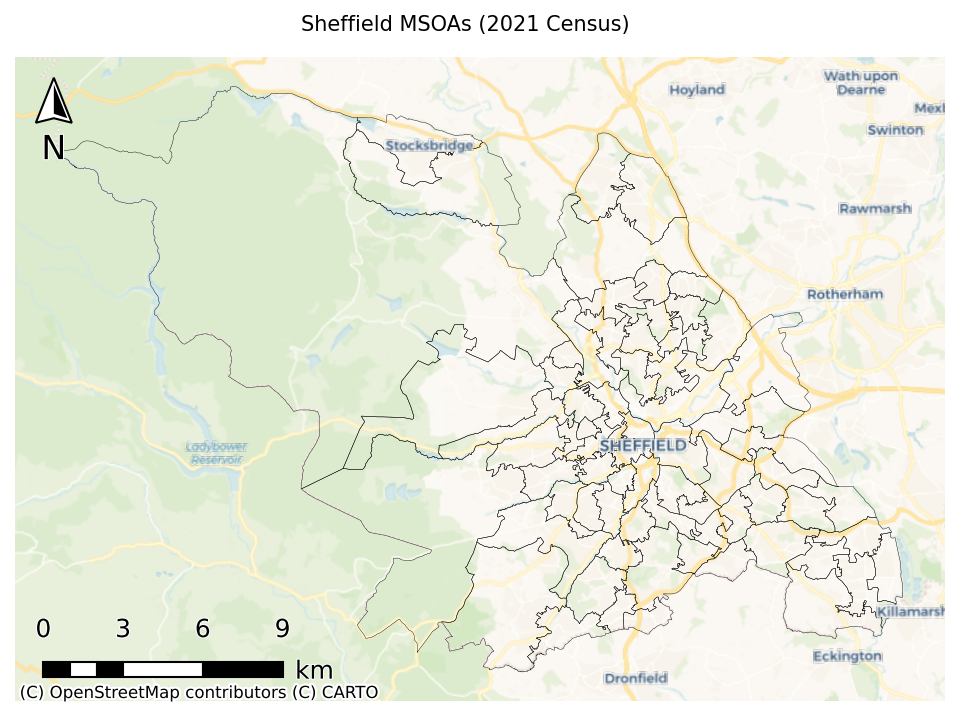

In [6]:
# @title
## Map
geo_msoa = geo_msoa.to_crs(epsg=27700)

##
f,ax = plt.subplots(1, figsize=(8,6))

## LSOA outlines are plotted as a base, as contextual information
geo_msoa.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.2)

# a CARTO basemap is added as further context for the study area
ctx.add_basemap(ax, crs=geo_msoa.crs, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=11)
ctx.add_basemap(ax, crs=geo_msoa.crs, source=ctx.providers.CartoDB.VoyagerOnlyLabels, zoom=11)

# remove axis
ax.set_axis_off()

# set figure title and resolution
f.suptitle('Sheffield MSOAs (2021 Census)', y=0.9, fontsize=10)
f.set_dpi(150)

# suppress a warning from the scale bar function
warnings.filterwarnings('ignore')

# north arrow and scale bar
north_arrow(ax, location="upper left", rotation={"crs":geo_msoa.crs, "reference":"center"}, shadow=False, scale=0.3)
scale_bar(ax, location="lower left", style="boxes", bar={"projection":geo_msoa.crs,"unit":"km"})

**Figure 1**.  The City of Sheffield defines the study area.  Sheffield's MSOAs are nested within the local authority district.

####**Outcome Variable of Interest**

**Edit:** New variable of interest defined as greenhouse gas emissions from domestic energy use (gas and electricity).

In [8]:
# @title
## Load gas and electricity consumption statistics from GitHub repository and read to pandas DataFrames.

## DESNZ Domestic Gas Consumption per MSOA (2021)
MSOA_GasUse = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/MSOA_domestic_gas_2010-2024.xlsx', sheet_name='2021', header=4, usecols='A:I')

## DESNZ Domestic Electricity Consumption per MSOA (2021)
MSOA_ElecUse = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/MSOA_domestic_elec_2010-2024.xlsx', sheet_name='2021', header=4, usecols='A:H')

## Subset gas and electricity use datasets and calculate greenhouse gas emissions per MSOA, for each energy source...
Sheff_GasUse = MSOA_GasUse.loc[MSOA_GasUse['Local authority']=='Sheffield', ['MSOA code', 'Total \nconsumption\n(kWh)']]
Sheff_GasUse['GHG Emissions / tCO2e'] = Sheff_GasUse['Total \nconsumption\n(kWh)']*0.18316/1000

Sheff_ElecUse = MSOA_ElecUse.loc[MSOA_GasUse['Local authority']=='Sheffield', ['MSOA code', 'Total \nconsumption\n(kWh)']]
Sheff_ElecUse['GHG Emissions / tCO2e'] = Sheff_ElecUse['Total \nconsumption\n(kWh)']*0.21233/1000

## ...And combine into a single energy use dataframe.
Sheff_EnergyUse = Sheff_GasUse.merge(Sheff_ElecUse, how='inner', on='MSOA code', suffixes=('_gas', '_elec'))


## Calculate total greenhouse gas emissions from domestic energy use (gas and electricity) per MSOA.
Sheff_EnergyUse['Total GHG Emissions / tCO2e'] = Sheff_EnergyUse['GHG Emissions / tCO2e_gas'] + Sheff_EnergyUse['GHG Emissions / tCO2e_elec']

Sheff_GHG = Sheff_EnergyUse[['MSOA code','Total GHG Emissions / tCO2e']]

## Display the first five records in the dataframe
Sheff_GHG.head()

,MSOA code,Total GHG Emissions / tCO2e
0,E02001611,10719.870760
1,E02001612,8424.282518
2,E02001613,13551.974080
3,E02001614,14923.322988
4,E02001615,11472.472447


In [9]:
# @title
## Load counts of households per MSOA from nomis API, merge with the Sheffield energy consumption dataset on an inner join and calculate the variable of interest, 'Greenhouse Gas Emissions per Household (kWh)'.
Sheff_HholdsCount = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2072_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_tenure_9=0&measures=20100&select=geography_code,obs_value')

Sheff_HholdsGHG = Sheff_GHG.merge(Sheff_HholdsCount, how='inner', left_on='MSOA code', right_on='GEOGRAPHY_CODE')

Sheff_HholdsGHG['GHG Emissions / tCO2e per household'] = Sheff_HholdsGHG['Total GHG Emissions / tCO2e']/Sheff_HholdsGHG['OBS_VALUE']

Sheff_HholdsGHG = Sheff_HholdsGHG[['MSOA code','GHG Emissions / tCO2e per household']].set_index('MSOA code')

## Display the first five records in the dataframe
Sheff_HholdsGHG.head()

,GHG Emissions / tCO2e per household
MSOA code,
E02001611,3.119869
E02001612,3.328440
E02001613,2.990946
E02001614,3.121381
E02001615,3.496639


In [10]:
# @title
## Calculate descriptive statistics on the variable of interest
Sheff_HholdsGHG.describe()

,GHG Emissions / tCO2e per household
count,70.000000
mean,3.078344
std,0.592396
min,1.550018
25%,2.736633
50%,2.960232
75%,3.330908
max,4.698761


In [11]:
# @title
## Join the energy consumption per household variable to the geopandas geodataframe containing MSOA boundaries on the MSOA code field.

geo_HholdsGHG = geo_msoa.merge(Sheff_HholdsGHG, left_on='MSOA21CD', right_on='MSOA code')

## Map the variable of interest as a choropleth

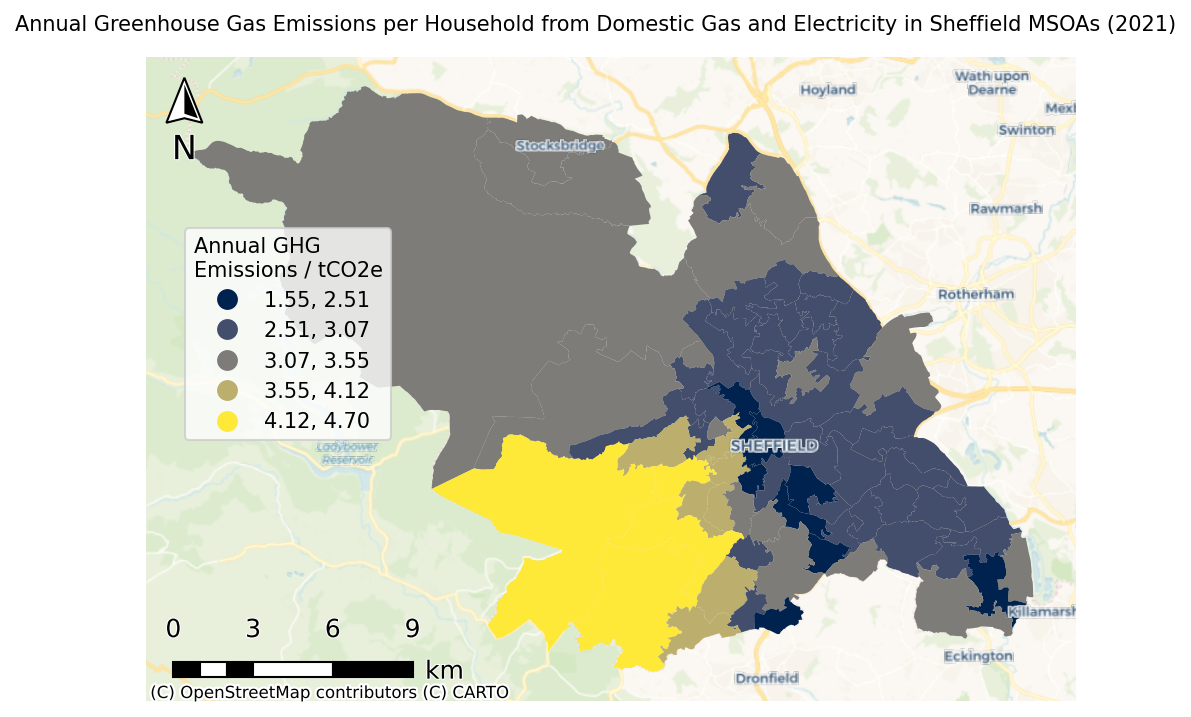

In [12]:
# @title
## Map
geo_HholdsGHG = geo_HholdsGHG.to_crs(epsg=27700)

##
f,ax = plt.subplots(1, figsize=(8,6))

## LSOA outlines are plotted as a base, as contextual information
geo_HholdsGHG.plot(ax=ax, column='GHG Emissions / tCO2e per household',legend=True, legend_kwds={'fontsize':'10','fmt':'{:.2f}','title':'Annual GHG\nEmissions / tCO2e'}, cmap='cividis',scheme='natural_breaks', linewidth=0.2)

# a CARTO basemap is added as further context for the study area
ctx.add_basemap(ax, crs=geo_HholdsGHG.crs, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=11)
ctx.add_basemap(ax, crs=geo_HholdsGHG.crs, source=ctx.providers.CartoDB.VoyagerOnlyLabels, zoom=11)

# remove axis
ax.set_axis_off()
ax.get_legend().set_bbox_to_anchor((.275, .75))

# set figure title and resolution
f.suptitle('Annual Greenhouse Gas Emissions per Household from Domestic Gas and Electricity in Sheffield MSOAs (2021)', y=0.9, fontsize=10)
f.set_dpi(150)

# suppress a warning from the scale bar function
warnings.filterwarnings('ignore')

# north arrow and scale bar
north_arrow(ax, location="upper left", rotation={"crs":geo_HholdsGHG.crs, "reference":"center"}, shadow=False, scale=0.3)
scale_bar(ax, location="lower left", style="boxes", bar={"projection":geo_HholdsGHG.crs,"unit":"km"})

**Figure 2**.  Mapping the variable of interest: annual, combined gas and electricity use per household exhibits clear spatial variation across the City, with high-energy consuming MSOAs strongly concentrated in south-west Sheffield.  The least energy-consuming MSOAs have a more dispersed, with some in the city centre but others distributed throughout south Sheffield.

####**Candidate Explanatory Variables**

*Justify choice of candidate variables with reference to a previous study of 'energy decadence' [] and proposed 'domains' of household energy behaviour, viz. building fabric, building occupants and disposable income.  Further justify choice of net disposable opposed to gross income*

Government statistics on estimated income [**A**], housing energy efficiency [**B**], domestic properties which are not connected to the gas grid [**C**] and domestic energy consumption at MSOA level [**D**] [**E**] are not available through APIs but are published as Microsoft Excel files to GOV.UK: versions of these datasets were accessed Wednesday 22 July 2026 and uploaded to the GitHub repository for this project.  The following code reads each dataset from GitHub to a pandas dataframe, in turn.

In [13]:
# @title

## ONS Income Estimates for Small Areas: Net annual income [after tax, before housing costs, non-equivalised] (2020)
MSOA_NetIncome = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/saiefy1920finalqaddownload280923.xlsx', sheet_name='Net annual income', header=4, usecols='A:J')

## Subsetting to the area of interest and candidate explanatory variable
Sheff_NetIncome = MSOA_NetIncome.loc[(MSOA_NetIncome['Local authority name']=='Sheffield'), ['MSOA code','Net annual income (£)']]

Sheff_NetIncome = Sheff_NetIncome.set_index('MSOA code')


## ONS Income Estimates for Small Areas: Net income after housing costs (2020)
MSOA_DispIncome = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/saiefy1920finalqaddownload280923.xlsx', sheet_name='Net income after housing costs', header=4, usecols='A:J')

## Subsetting to the area of interest and candidate explanatory variable
Sheff_DispIncome = MSOA_DispIncome.loc[(MSOA_DispIncome['Local authority name']=='Sheffield'), ['MSOA code','Net annual income after housing costs (£)']]

Sheff_DispIncome = Sheff_DispIncome.set_index('MSOA code')



## ONS Energy Efficiency of Housing per MSOA: Median estimated energy cost for existing housing (2021)
MSOA_Median_EPC = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/energyefficiencyofhousingenglandandwalesmiddlelayersuperoutputareauptomarch2021.xlsx', sheet_name='2a', header=3, usecols='A:E')

## Subsetting to the area of interest and candidate explanatory variable
Sheff_Median_EPC = MSOA_Median_EPC.loc[(MSOA_Median_EPC['Local authority district name']=='Sheffield'), ['Middle super output layer (MSOA) code','Existing dwellings']]

Sheff_Median_EPC = Sheff_Median_EPC.set_index('Middle super output layer (MSOA) code')

Sheff_Median_EPC = Sheff_Median_EPC.rename(columns={'Existing dwellings':'Median energy efficiency score'})


## ONS Energy Efficiency of Housing per MSOA: Median estimated energy cost for existing housing (2021)
MSOA_Median_EnergyCost = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/energyefficiencyofhousingenglandandwalesmiddlelayersuperoutputareauptomarch2021.xlsx', sheet_name='2e', header=3, usecols='A:E')

## Subsetting to the area of interest and candidate explanatory variable
Sheff_EnergyCost = MSOA_Median_EnergyCost.loc[(MSOA_Median_EnergyCost['Local authority district name']=='Sheffield'), ['Middle super output layer (MSOA) code','Existing dwellings']]

Sheff_EnergyCost = Sheff_EnergyCost.set_index('Middle super output layer (MSOA) code')

Sheff_EnergyCost = Sheff_EnergyCost.rename(columns={'Existing dwellings':'Median estimated energy cost (£)'})



## DESNZ Domestic Properties not on the Gas Grid per MSOA (2021)
MSOA_NotGas = pd.read_excel('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/MSOA_estimates_of_properties_not_connected_to_the_gas_network_2015-2024.xlsx', sheet_name='2021', header=3, usecols='A:H')

## Subsetting to the area of interest and candidate explanatory variable
Sheff_NotGas = MSOA_NotGas.loc[MSOA_NotGas['Local authority']=='Sheffield',['MSOA code','Estimated percentage\nof properties not \non the gas grid']]

Sheff_NotGas = Sheff_NotGas.set_index('MSOA code')

Sheff_NotGas = Sheff_NotGas.rename(columns={'Estimated percentage\nof properties not \non the gas grid':'PercentNotGas'}).mul(100)

A Department for Transport dataset with cumulative counts of licensed plug-in vehicles per LSOA [**F**] is too large to upload to GitHub directly: see the commented-out code below for steps taken to obtain data for the area of interest only, to be uploaded to GitHub.

In [ ]:
## Reading DfT 'Licensed plug-in vehicles' LSOA dataset to a pandas dataframe for subsetting as the original file is too large to upload to GitHub (57.8MB).

#df = pd.read_csv('./df_VEH0145.csv')


## Selecting records for LSOAs within Sheffield local authority district, where vehicles are in private, opposed to company keepership.  'Total' fuel includes both battery electric and plug in hybrid electric vehicles.  Data for 2025 Q1 quarter end are selected.

Sheff_PiV_25 = df.loc[((df['LSOA21NM'].str.contains('Sheffield')) & (df['Keepership'] == 'Private') & (df['Fuel'] == 'Total')), ['LSOA21CD', 'LSOA21NM', 'Fuel', 'Keepership', '2025 Q1']]


## Saving the subset plug-in vehicles data to a csv file for uploading manually to GitHub.
#Sheff_PiV_25.to_csv('./Sheff_PiV_25.csv')


## Reading subset PiV data from GitHub to a pandas dataframe for analysis.
Sheff_PiV_25 = pd.read_csv('https://github.com/jwsn8667/GEOG5003M/raw/refs/heads/main/Sheff_PiV_25.csv')

2021 Census data on households' tenure [**G**] and occupancy rating for bedrooms [**H**], the share of detached housing [**I**] and the share of population aged over 65 [**J**] are accessed using nomis API to query only those records relating to the area of interest.  Some reprocessing is required *e.g.*, to determine the share of households which are over-occupied for bedrooms from the sum of households which have occupancy ratings of '+1' and '+2 or more'.

In [14]:
## Census Total Population (2021)
Sheff_Pop = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2018_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_age_12a=0&measures=20100&select=geography_code,obs_value')
Sheff_Pop = Sheff_Pop.merge(Sheff_HholdsCount, how='inner', left_on='GEOGRAPHY_CODE', right_on='GEOGRAPHY_CODE').set_index('GEOGRAPHY_CODE')
Sheff_Pop['MeanPersonsPerHousehold'] = Sheff_Pop['OBS_VALUE_x']/Sheff_Pop['OBS_VALUE_y']
Sheff_HholdPers = Sheff_Pop['MeanPersonsPerHousehold']

Sheff_HholdPers.head()

,MeanPersonsPerHousehold
GEOGRAPHY_CODE,
E02001611,2.236903
E02001612,2.218886
E02001613,2.254469
E02001614,2.300356
E02001615,2.175861


In [103]:
## Census Central Heating: Electric only or District or communal heat networks only (2021)
Sheff_CentralHeating = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2064_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_heating_13=4,9&measures=20301&select=geography_code,c2021_heating_13_name,obs_value')

Sheff_CentralHeating = Sheff_CentralHeating.pivot(columns='C2021_HEATING_13_NAME', index='GEOGRAPHY_CODE', values='OBS_VALUE').rename(columns={'District or communal heat networks only':'PercentDistrictHeating','Electric only':'PercentElectricHeating'})

Sheff_CentralHeating

C2021_HEATING_13_NAME,PercentDistrictHeating,PercentElectricHeating
GEOGRAPHY_CODE,,
E02001611,0.5,2.2
E02001612,0.2,2.5
E02001613,1.3,2.2
E02001614,0.5,2.7
E02001615,0.3,1.8
...,...,...
E02006803,0.2,4.5
E02006843,1.5,68.2
E02006844,1.8,47.1


In [104]:
# @title
## Census Tenure of Household: Owns outright or owns with a mortgage or a loan  (2021)
Sheff_OwnsOutright = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2072_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_tenure_9=1&measures=20301&select=geography_code,obs_value')
Sheff_OwnsOutright = Sheff_OwnsOutright.set_index('GEOGRAPHY_CODE').rename(columns={'OBS_VALUE':'PercentOwnsOutright'})



## Census Tenure of Household: Social rented  (2021)
Sheff_SocialRent = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2072_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_tenure_9=1003&measures=20301&select=geography_code,obs_value')

Sheff_SocialRent = Sheff_SocialRent.set_index('GEOGRAPHY_CODE').rename(columns={'OBS_VALUE':'PercentSocialRented'})



## Census Total Population (2021)
Sheff_Pop = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2018_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_age_12a=0&measures=20100&select=geography_code,obs_value')

## Deriving mean number of persons per household variable
Sheff_Pop = Sheff_Pop.merge(Sheff_HholdsCount, how='inner', left_on='GEOGRAPHY_CODE', right_on='GEOGRAPHY_CODE').set_index('GEOGRAPHY_CODE')
Sheff_Pop['MeanPersonsPerHousehold'] = Sheff_Pop['OBS_VALUE_x']/Sheff_Pop['OBS_VALUE_y']
Sheff_HholdPers = Sheff_Pop['MeanPersonsPerHousehold']



## Census Occupancy Rating for Rooms: Occupancy rating for rooms -2 or less (2021)
Sheff_OverOccup = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2071_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_occrat_rooms_6=5&measures=20301&select=geography_code,obs_value')

Sheff_OverOccup = Sheff_OverOccup.set_index('GEOGRAPHY_CODE').rename(columns={'OBS_VALUE':'PercentOverOccupied'})



## Census Full-time Students by Age (2021)
Sheff_AdultStudent = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2306_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_student_3=1&c2021_age_7b=3...6&measures=20100&select=geography_code,c2021_age_7b_name,obs_value')

Sheff_AdultStudent = Sheff_AdultStudent.pivot(columns='C2021_AGE_7B_NAME', index='GEOGRAPHY_CODE', values='OBS_VALUE')

Sheff_AdultStudent['AdultStudentPopulation'] = Sheff_AdultStudent['Aged 18 to 20 years'] + Sheff_AdultStudent['Aged 21 to 24 years'] + Sheff_AdultStudent['Aged 25 to 29 years'] + Sheff_AdultStudent['Aged 30 years and over']


## Census Central Heating: Electric only or District or communal heat networks only (2021)
Sheff_CentralHeating = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2064_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_heating_13=4,9&measures=20301&select=geography_code,c2021_heating_13_name,obs_value')

Sheff_CentralHeating = Sheff_CentralHeating.pivot(columns='C2021_HEATING_13_NAME', index='GEOGRAPHY_CODE', values='OBS_VALUE').rename(columns={'District or communal heat networks only':'PercentDistrictHeating','Electric only':'PercentElectricHeating'})


## Deriving mean number of students per household variable
Sheff_AdultStudent = Sheff_AdultStudent.reset_index()

Sheff_AdultStudent = Sheff_AdultStudent.merge(Sheff_HholdsCount, how='inner', left_on='GEOGRAPHY_CODE', right_on='GEOGRAPHY_CODE').set_index('GEOGRAPHY_CODE')

Sheff_AdultStudent['MeanStudentsPerHousehold'] = Sheff_AdultStudent['AdultStudentPopulation']/Sheff_AdultStudent['OBS_VALUE']

Sheff_HholdStudnt = Sheff_AdultStudent['MeanStudentsPerHousehold']



## Census Accommodation Type: Detached (2021)
Sheff_Detached = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2062_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_acctype_9=1&measures=20301&select=geography_code,obs_value')
Sheff_Detached = Sheff_Detached.set_index('GEOGRAPHY_CODE').rename(columns={'OBS_VALUE':'PercentDetached'})


## Census Ethnic Group (2021)
Sheff_WhiteBritish = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2041_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_eth_20=1&measures=20301&select=geography_code,obs_value')

Sheff_WhiteBritish = Sheff_WhiteBritish.set_index('GEOGRAPHY_CODE').rename(columns={'OBS_VALUE':'PercentWhiteBritish'})


## Census Age by Broad Age Bands (2021)
Sheff_AgeBands = pd.read_csv('https://www.nomisweb.co.uk/api/v01/dataset/NM_2018_1.data.csv?date=latest&geography=637535754...637535818,637540760,637540800,637540801,637540824,637540825&c2021_age_12a=9...11&measures=20301&select=geography_code,c2021_age_12a_name,obs_value')

## Deriving share of population aged over 65 years
Sheff_AgeBands = Sheff_AgeBands.pivot(columns = 'C2021_AGE_12A_NAME', index='GEOGRAPHY_CODE', values='OBS_VALUE')

Sheff_AgeBands['PercentOver65'] = Sheff_AgeBands['Aged 65 to 74 years'] + Sheff_AgeBands['Aged 75 to 84 years'] + Sheff_AgeBands['Aged 85 years and over']

Sheff_Over65 = Sheff_AgeBands['PercentOver65']

In [106]:
# @title
## Concatenating all candidate explanatory variables in a single dataframe
Explanatory_Variables = pd.concat([Sheff_NetIncome, Sheff_DispIncome, Sheff_Median_EPC, Sheff_EnergyCost, Sheff_NotGas, Sheff_OwnsOutright, Sheff_SocialRent, Sheff_HholdPers, Sheff_OverOccup, Sheff_HholdStudnt, Sheff_Detached, Sheff_WhiteBritish, Sheff_Over65, Sheff_CentralHeating], axis=1)

In [117]:
Explanatory_Variables['Energy costs as a percentage of net annual income'] = 100*Explanatory_Variables['Median estimated energy cost (£)']/Explanatory_Variables['Net annual income (£)']

Explanatory_Variables['Net annual income after housing and energy costs (£)'] = Explanatory_Variables['Net annual income after housing costs (£)'] - Explanatory_Variables['Median estimated energy cost (£)']

Explanatory_Variables['GIA_Proxy'] = Explanatory_Variables['Median energy efficiency score']/Explanatory_Variables['Median estimated energy cost (£)']

Explanatory_Variables['Alt_Proxy'] = Explanatory_Variables['Median estimated energy cost (£)']/Explanatory_Variables['Median energy efficiency score']

Explanatory_Variables.describe()

,Net annual income (£),Net annual income after housing costs (£),Median energy efficiency score,Median estimated energy cost (£),PercentNotGas,PercentOwnsOutright,PercentSocialRented,MeanPersonsPerHousehold,PercentOverOccupied,MeanStudentsPerHousehold,PercentDetached,PercentWhiteBritish,PercentOver65,PercentDistrictHeating,PercentElectricHeating,Energy costs as a percentage of net annual income,Net annual income after housing and energy costs (£),GIA_Proxy,Alt_Proxy
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,29804.285714,25577.142857,64.442857,789.242857,9.029571,30.991429,22.687143,2.409965,1.011429,0.224455,14.970000,76.022857,17.395714,2.085714,7.078571,2.655915,24787.900000,0.086887,12.469817
std,5486.331784,5716.317134,4.448207,170.579612,15.087193,12.208998,16.241198,0.301629,1.204165,0.398279,13.996307,19.817692,6.446827,2.532415,10.020152,0.377889,5583.475584,0.026300,3.491240
min,21700.000000,16800.000000,55.000000,404.000000,0.000000,5.400000,1.900000,2.021875,0.000000,0.036879,0.400000,17.300000,1.200000,0.000000,1.600000,1.374150,16092.000000,0.047923,5.246753
25%,25725.000000,20975.000000,62.000000,674.500000,2.147500,21.200000,9.625000,2.237329,0.200000,0.053736,5.025000,68.200000,13.400000,0.425000,2.925000,2.488674,20309.500000,0.068719,10.000000
50%,28700.000000,24400.000000,65.000000,776.000000,4.340000,31.900000,17.350000,2.313143,0.600000,0.064752,9.250000,82.700000,16.600000,1.200000,4.650000,2.648433,23619.500000,0.083919,11.916434
75%,32825.000000,28825.000000,67.000000,889.250000,8.615000,39.900000,39.375000,2.461795,1.275000,0.135462,21.600000,90.650000,23.075000,2.500000,6.775000,2.853167,27875.750000,0.100003,14.552995
max,45200.000000,43700.000000,77.000000,1252.000000,88.160000,54.100000,59.400000,3.462201,5.600000,1.635994,56.300000,96.200000,30.900000,12.100000,68.200000,4.089552,42587.000000,0.190594,20.866667


In [ ]:
## Open Geography Portal API for lookup tables

####**Exploratory Analysis**

In [ ]:
## Descriptive statistics

In [118]:
# @title
## Testing for collinearity between pairs of candidate explanatory variables.
Corr_Matrix = Explanatory_Variables.corr().style.map(lambda v: "color:red;" if (1.0 > v > 0.8) or (v < -0.8) else None)
Corr_Matrix

,Net annual income (£),Net annual income after housing costs (£),Median energy efficiency score,Median estimated energy cost (£),PercentNotGas,PercentOwnsOutright,PercentSocialRented,MeanPersonsPerHousehold,PercentOverOccupied,MeanStudentsPerHousehold,PercentDetached,PercentWhiteBritish,PercentOver65,PercentDistrictHeating,PercentElectricHeating,Energy costs as a percentage of net annual income,Net annual income after housing and energy costs (£),GIA_Proxy,Alt_Proxy
Net annual income (£),1.000000,0.960639,-0.566977,0.781840,-0.032269,0.701993,-0.786839,0.025697,-0.538787,0.060499,0.646552,0.410187,0.400510,-0.389215,-0.063061,-0.114195,0.959609,-0.616073,0.750968
Net annual income after housing costs (£),0.960639,1.000000,-0.565345,0.784637,-0.080955,0.760335,-0.798324,-0.138090,-0.616674,-0.052000,0.643407,0.489447,0.498059,-0.355171,-0.123605,-0.057613,0.999821,-0.631823,0.748252
Median energy efficiency score,-0.566977,-0.565345,1.000000,-0.895487,0.447227,-0.527781,0.617451,-0.110328,0.214686,0.136423,-0.204237,-0.209830,-0.209464,0.272935,0.418074,-0.648149,-0.551438,0.920384,-0.937279
Median estimated energy cost (£),0.781840,0.784637,-0.895487,1.000000,-0.407016,0.740114,-0.705635,0.029874,-0.334318,-0.216288,0.483555,0.318514,0.439595,-0.276824,-0.408938,0.525394,0.772754,-0.934478,0.989728
PercentNotGas,-0.032269,-0.080955,0.447227,-0.407016,1.000000,-0.410057,-0.051433,0.404614,0.134509,0.761068,-0.190731,-0.395363,-0.498973,0.167521,0.944925,-0.605893,-0.070446,0.626501,-0.373040
PercentOwnsOutright,0.701993,0.760335,-0.527781,0.740114,-0.410057,1.000000,-0.691648,-0.292445,-0.519633,-0.446104,0.800092,0.601430,0.866081,-0.202708,-0.489548,0.236701,0.755814,-0.728298,0.668447
PercentSocialRented,-0.786839,-0.798324,0.617451,-0.705635,-0.051433,-0.691648,1.000000,-0.063468,0.460903,-0.150868,-0.549401,-0.348789,-0.325701,0.345243,-0.036054,-0.057706,-0.795760,0.603680,-0.701437
MeanPersonsPerHousehold,0.025697,-0.138090,-0.110328,0.029874,0.404614,-0.292445,-0.063468,1.000000,0.592467,0.658921,-0.137066,-0.666076,-0.590498,0.051622,0.410047,0.045890,-0.142288,0.043609,0.078808
PercentOverOccupied,-0.538787,-0.616674,0.214686,-0.334318,0.134509,-0.519633,0.460903,0.592467,1.000000,0.143924,-0.398030,-0.905350,-0.549252,0.431352,0.213222,0.233920,-0.621132,0.311205,-0.298261
MeanStudentsPerHousehold,0.060499,-0.052000,0.136423,-0.216288,0.761068,-0.446104,-0.150868,0.658921,0.143924,1.000000,-0.251804,-0.360074,-0.633173,-0.042258,0.744403,-0.434702,-0.046629,0.356546,-0.155572


**Table 1**.  Correlation matrix: screening for collinearity between candidate explanatory variables.  A threshold magnitude of 0.8 is applied to the values of Pearson's correlation test statistic (r-values) summarised in the table: above this threshold, pairs of variables are considered strongly collinear and should not both be included as explanatory variables in statistical modelling, as indicated by red highlight text [*note this formatting is not rendered in the preview on GitHub*].

In [119]:
from pydantic.types import AllowInfNan
# @title
All_Variables = pd.concat([Sheff_HholdsGHG,Explanatory_Variables], axis=1)

All_Variables.head()

,GHG Emissions / tCO2e per household,Net annual income (£),Net annual income after housing costs (£),Median energy efficiency score,Median estimated energy cost (£),PercentNotGas,PercentOwnsOutright,PercentSocialRented,MeanPersonsPerHousehold,PercentOverOccupied,MeanStudentsPerHousehold,PercentDetached,PercentWhiteBritish,PercentOver65,PercentDistrictHeating,PercentElectricHeating,Energy costs as a percentage of net annual income,Net annual income after housing and energy costs (£),GIA_Proxy,Alt_Proxy
E02001611,3.119869,28800,25000,66,783,1.89,39.3,15.5,2.236903,0.3,0.041036,21.7,95.4,24.6,0.5,2.2,2.718750,24217,0.084291,11.863636
E02001612,3.328440,31800,28400,64,854,4.37,44.2,9.7,2.218886,0.2,0.053734,39.9,96.2,23.5,0.2,2.5,2.685535,27546,0.074941,13.343750
E02001613,2.990946,29900,25100,65,778,3.74,38.9,19.6,2.254469,0.4,0.039947,25.9,93.8,23.8,1.3,2.2,2.602007,24322,0.083548,11.969231
E02001614,3.121381,31700,28100,64,822,1.04,44.0,8.8,2.300356,0.1,0.045806,28.9,94.6,25.4,0.5,2.7,2.593060,27278,0.077859,12.843750
E02001615,3.496639,32500,30300,62,919,2.45,53.9,4.3,2.175861,0.2,0.036879,31.6,93.8,30.9,0.3,1.8,2.827692,29381,0.067465,14.822581


''

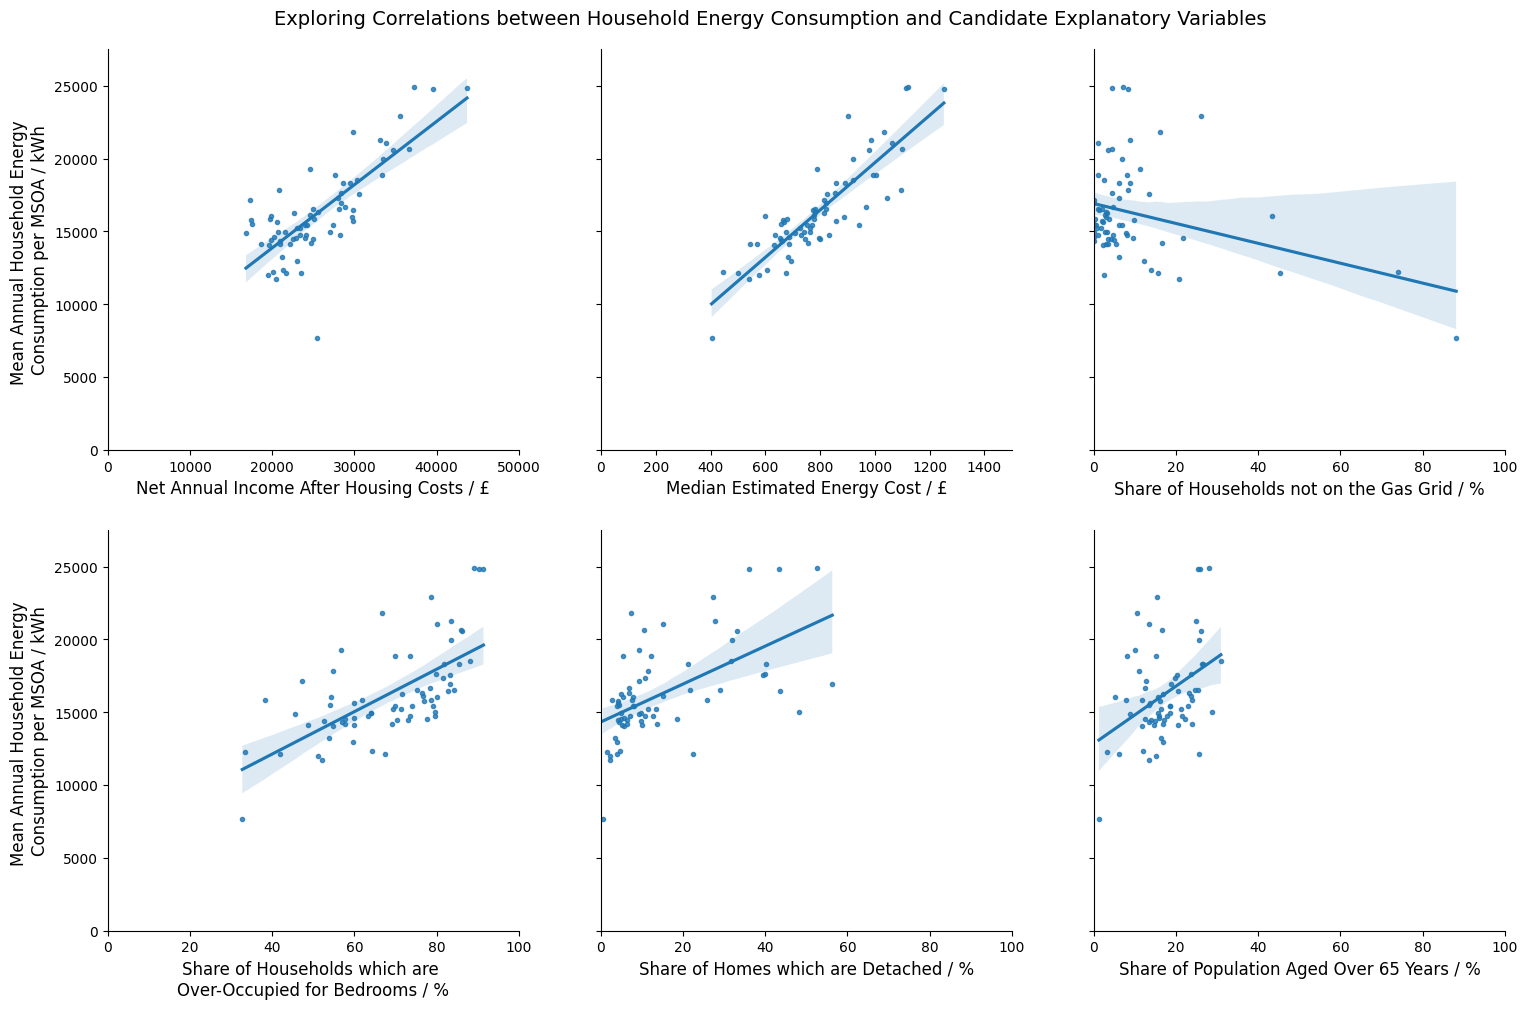

In [ ]:
# @title
MV = Model_Variables.reset_index().rename(columns={'index':'MSOA code'})

melt = pd.melt(MV, id_vars=['MSOA code','EnergyConsumptionPerHousehold(kWh)'], value_vars=['Net annual income after housing costs (£)', 'Median estimated energy cost (£)', 'PercentNotGas', 'PercentOverOccupied', 'PercentDetached', 'PercentOver65'])

## Plotting
g = sns.lmplot(data=melt, x='value', y='EnergyConsumptionPerHousehold(kWh)', col='variable', seed=42, facet_kws={'sharey': True, 'sharex': False}, col_wrap=3, markers='.')

g.set_titles('')
g.set(ylim=(0, 27500), ylabel='Mean Annual Household Energy \nConsumption per MSOA / kWh')

for ax in g.axes.flat:
       # This only works for the left ylabels
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)

g.axes[0].set_xlabel('Net Annual Income After Housing Costs / £', fontsize=12)
g.axes[0].set(xlim=(0, 50000))

g.axes[1].set_xlabel('Median Estimated Energy Cost / £', fontsize=12)
g.axes[1].set(xlim=(0, 1500))

g.axes[2].set_xlabel('Share of Households not on the Gas Grid / %', fontsize=12)
g.axes[2].set(xlim=(0, 100))

g.axes[3].set_xlabel('Share of Households which are \nOver-Occupied for Bedrooms / %', fontsize=12)
g.axes[3].set(xlim=(0, 100))

g.axes[4].set_xlabel('Share of Homes which are Detached / %', fontsize=12)
g.axes[4].set(xlim=(0, 100))

g.axes[5].set_xlabel('Share of Population Aged Over 65 Years / %', fontsize=12)
g.axes[5].set(xlim=(0, 100))

g.fig.suptitle('Exploring Correlations between Household Energy Consumption and Candidate Explanatory Variables', fontsize=14)
g.fig.subplots_adjust(top=.94)

g.fig.subplots_adjust(wspace=0.2, hspace=0.2)
;

In [121]:
# @title
from scipy.stats import pearsonr

def pearsonr_pval(x, y):
    return pearsonr(x, y)[1]

r_df = All_Variables.corr(method="pearson").reset_index().iloc[0,2:21].pow(2).reset_index().rename(columns={'index':'Candidate Explanatory Variable', 0:'R-squared'})

p_df = All_Variables.corr(method=pearsonr_pval).reset_index().iloc[0,2:21].reset_index().rename(columns={'index':'Candidate Explanatory Variable', 0:'p'})

df = r_df.merge(p_df, on='Candidate Explanatory Variable').sort_values(by=['R-squared'], ascending=False)
df = df.style.map(lambda v: "color:red;" if (v > 0.05) else None, subset=['p'])
df

,Candidate Explanatory Variable,R-squared,p
3,Median estimated energy cost (£),0.746048,0.000000
0,Net annual income (£),0.690310,0.000000
18,Alt_Proxy,0.686163,0.000000
17,GIA_Proxy,0.614710,0.000000
1,Net annual income after housing costs (£),0.609728,0.000000
16,Net annual income after housing and energy costs (£),0.597592,0.000000
2,Median energy efficiency score,0.486659,0.000000
5,PercentOwnsOutright,0.464464,0.000000
6,PercentSocialRented,0.382094,0.000000
10,PercentDetached,0.328447,0.000000


**Table 2**.  Pearson correlation test statistics for each candidate explanatory variable with mean annual household energy consumption.

###Statistical Modelling

In [126]:
import numpy as np
from sklearn.linear_model import LinearRegression

# creating feature variables
X = All_Variables[['Net annual income (£)','GIA_Proxy','PercentOwnsOutright', 'PercentSocialRented', 'PercentDistrictHeating', 'PercentElectricHeating', 'PercentOverOccupied', 'MeanStudentsPerHousehold']]
y = All_Variables['GHG Emissions / tCO2e per household']

reg = LinearRegression().fit(X, y)

print(reg.score(X, y))
print(reg.intercept_)
print(reg.coef_)

residuals = 100*(reg.predict(X) - y)/y
residuals = residuals.reset_index().rename(columns = {'GHG Emissions / tCO2e per household':'PercentageResidual', 'index':'MSOA code'})
residuals

0.9369710845521366
0.6090115317426408
[ 7.07466572e-05 -1.06369006e+01  2.30865601e-02  1.80597705e-02
 -4.10465176e-02 -5.05221984e-03  1.44192641e-01  6.02861396e-01]


,MSOA code,PercentageResidual
0,E02001611,-4.691351
1,E02001612,-0.926305
2,E02001613,3.812404
3,E02001614,2.714401
4,E02001615,1.307267
...,...,...
65,E02006803,4.326785
66,E02006843,1.848940
67,E02006844,1.490943
68,E02006868,-0.482196


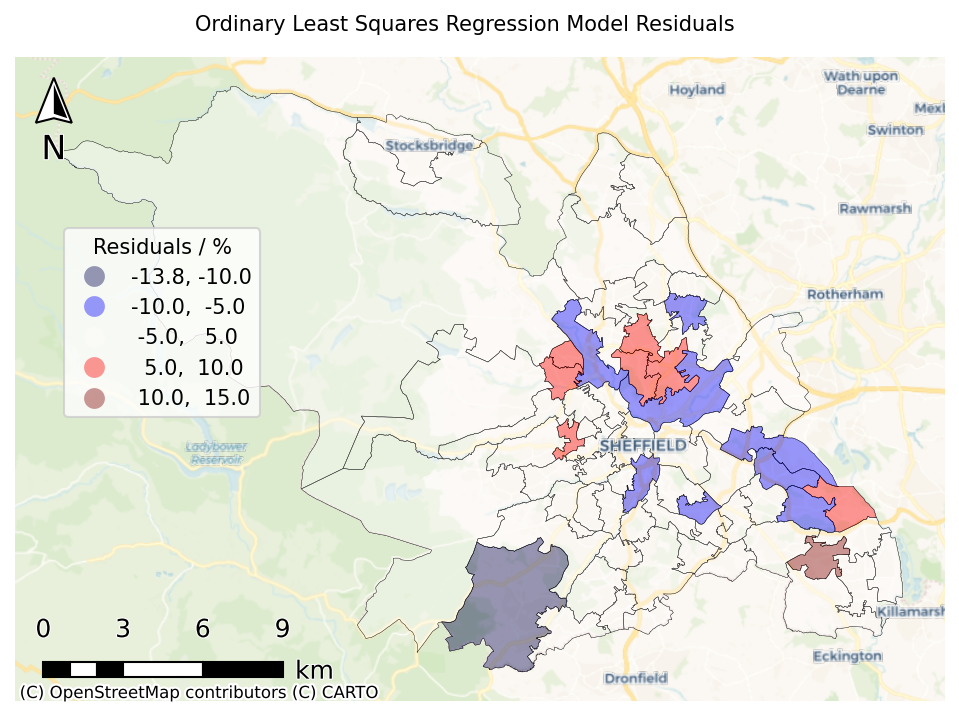

In [130]:
geo_residuals = geo_msoa.merge(residuals, left_on='MSOA21CD', right_on='MSOA code')

##
f,ax = plt.subplots(1, figsize=(8,6))

custom_bins = [-10, -5, 5, 10, 15]

## LSOA outlines are plotted as a base, as contextual information
base = geo_msoa.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.2)

##
geo_residuals.plot(ax=base, column='PercentageResidual',legend=True, legend_kwds={'fontsize':'10','fmt':'{:.1f}','title':'Residuals / %'}, cmap='seismic',scheme='user_defined', classification_kwds={'bins': custom_bins}, linewidth=0.2, edgecolor='black', alpha=0.4)

# a CARTO basemap is added as further context for the study area
ctx.add_basemap(ax, crs=geo_residuals.crs, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=11)
ctx.add_basemap(ax, crs=geo_residuals.crs, source=ctx.providers.CartoDB.VoyagerOnlyLabels, zoom=11)

# remove axis
ax.set_axis_off()
ax.get_legend().set_bbox_to_anchor((.275, .75))

# set figure title and resolution
f.suptitle('Ordinary Least Squares Regression Model Residuals', y=0.9, fontsize=10)
f.set_dpi(150)

# suppress a warning from the scale bar function
warnings.filterwarnings('ignore')

# north arrow and scale bar
north_arrow(ax, location="upper left", rotation={"crs":geo_residuals.crs, "reference":"center"}, shadow=False, scale=0.3)
scale_bar(ax, location="lower left", style="boxes", bar={"projection":geo_residuals.crs,"unit":"km"})

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# creating feature variables
X = Model_Variables.drop('EnergyConsumptionPerHousehold(kWh)', axis=1)
y = Model_Variables['EnergyConsumptionPerHousehold(kWh)']

reg = LinearRegression().fit(X, y)

print(reg.score(X, y))
print(reg.intercept_)
print(reg.coef_)

resi2uals = 100*(reg.predict(X) - y)/y
resi2uals = resi2uals.reset_index().rename(columns = {'EnergyConsumptionPerHousehold(kWh)':'PercentageResidual', 'index':'MSOA code'})
resi2uals

0.8264544805060225
6645.187718173631
[  0.24828156  12.18813065 -43.46043264 -90.31913471  57.00486541
 -34.28377781]


,MSOA code,PercentageResidual
0,E02001611,-3.759621
1,E02001612,3.061557
2,E02001613,-0.530178
3,E02001614,1.471509
4,E02001615,-2.773107
...,...,...
65,E02006803,7.569892
66,E02006843,43.981712
67,E02006844,-11.466237
68,E02006868,-3.460708


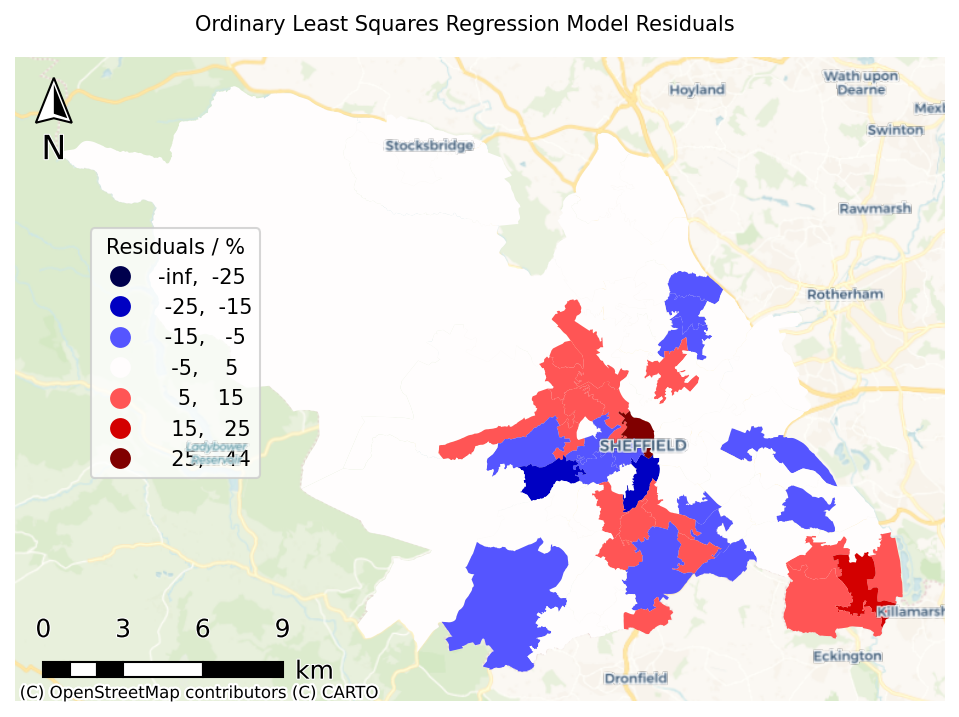

In [ ]:
geo_resi2uals = geo_msoa.merge(resi2uals, left_on='MSOA21CD', right_on='MSOA code')

##
f,ax = plt.subplots(1, figsize=(8,6))

custom_bins = [-25, -15, -5, 5, 15, 25]

## LSOA outlines are plotted as a base, as contextual information
geo_resi2uals.plot(ax=ax, column='PercentageResidual',legend=True, legend_kwds={'fontsize':'10','fmt':'{:.0f}','title':'Residuals / %'}, cmap='seismic',scheme='user_defined', classification_kwds={'bins': custom_bins}, linewidth=0.2)

# a CARTO basemap is added as further context for the study area
ctx.add_basemap(ax, crs=geo_HholdsEnergy.crs, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=11)
ctx.add_basemap(ax, crs=geo_HholdsEnergy.crs, source=ctx.providers.CartoDB.VoyagerOnlyLabels, zoom=11)

# remove axis
ax.set_axis_off()
ax.get_legend().set_bbox_to_anchor((.275, .75))

# set figure title and resolution
f.suptitle('Ordinary Least Squares Regression Model Residuals', y=0.9, fontsize=10)
f.set_dpi(150)

# suppress a warning from the scale bar function
warnings.filterwarnings('ignore')

# north arrow and scale bar
north_arrow(ax, location="upper left", rotation={"crs":geo_HholdsEnergy.crs, "reference":"center"}, shadow=False, scale=0.3)
scale_bar(ax, location="lower left", style="boxes", bar={"projection":geo_HholdsEnergy.crs,"unit":"km"})

In [ ]:
## Elbow plot

In [ ]:
## K-means cluster analysis

#Results

###Non-Spatial Data Visualisation

In [ ]:
## Non-spatial data visualisation



*   Justifying visualisation choices for accessibility, data density *etc*.



###Spatial Data Visualisation

In [ ]:
## Spatial data visualisation



*   Justifying visualisation choices...



#Discussion



*   Interpretation of K-means clusters
*   Implications for local climate change policy
*   Suggestions for further research



#References




1.   List item
2.   List item